# Section 0: Foundation + Setup (Day 1)

## 1. WHAT IS GENERATIVE AI?

Generative AI (GenAI) = AI that can create new content, not just analyze.

🔹 Examples
Text → ChatGPT
Images → DALL·E / Stable Diffusion
Code → GitHub Copilot
Audio → Voice models

Unlike traditional ML:

ML → predicts/classifies
GenAI → generates
## 2. TYPES OF GENERATIVE AI MODELS

1. LLMs (Large Language Models)
Work with text
Based on transformers

🔹 Examples:

GPT, Llama, Mistral
2. Diffusion Models
Work with images/video
Add noise → remove noise → generate image

🔹 Examples:

Stable Diffusion
DALL·E
3. GANs (Generative Adversarial Networks)
Two networks compete:
Generator
Discriminator

🔹 Used for:

Face generation
Image enhancement
##  3. LLM vs DIFFUSION vs GAN
Feature	LLM	Diffusion	GAN
Data type	Text	Images/Video	Images
Training style	Transformer	Noise-based	Adversarial
Output quality	High (text)	Very high (images)	High but unstable
Control	High	Medium	Low
Stability	Stable	Stable	Hard to train

🔹 Interview Tip:

LLM = language
Diffusion = realistic images
GAN = older image generation method
## 4. API-BASED vs LOCAL MODELS
🔹 API-Based Models
Hosted by companies
Pros:

✔ Easy to use
✔ No GPU needed
✔ High performance

Cons:

❌ Cost
❌ Internet required
❌ Data privacy concerns

🔹 Local Models (Open-source)
Pros:

✔ Free
✔ Private
✔ Customizable

Cons:

❌ Need GPU
❌ Setup complexity
❌ Slightly lower performance

## 5. FREE MODEL ECOSYSTEM

Popular Open Models:
Meta Llama
Mistral
Falcon
Gemma (Google)
HuggingFace models
Tools:
Ollama → run locally
HuggingFace Transformers
LM Studio

## 6. MODEL LANDSCAPE COMPARISON

Now the important part for your assignment 👇

🔹 A. MODEL PROVIDERS OVERVIEW
1. OpenAI
GPT models
Best for production-grade apps
2. Google (Gemini)
Strong reasoning + multimodal
3. Meta (Llama)
Open-source friendly
4. Mistral AI
Fast + efficient open models
5. Hugging Face
Hub for thousands of models

📊 B. MODEL COMPARISON TABLE

Model Provider	Cost	Speed	Strengths	Best Use Cases
OpenAI (GPT-4/4o)	$$$	Medium	Best reasoning, accuracy	Chatbots, production apps
Google Gemini	$$	Fast	Multimodal, long context	Search, analytics
Meta Llama	Free	Medium	Open-source, customizable	Local apps, research
Mistral AI	Free / Low	Very Fast	Lightweight, efficient	Real-time apps
Hugging Face Models	Free	Varies	Huge variety	Experimentation


In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

In [2]:
import os
import google.generativeai as genai


def configure_api():
    """
    Configure the Gemini API using an environment variable.
    """
    api_key = os.getenv("GEMINI_API_KEY")
    if not api_key:
        raise ValueError("GEMINI_API_KEY not found in environment variables.")
    
    genai.configure(api_key=api_key)


def create_model(model_name: str = "gemini-pro"):
    """
    Initialize and return a Generative AI model.
    """
    return genai.GenerativeModel(model_name)


def generate_response(model, prompt: str) -> str:
    """
    Generate a response from the model based on the given prompt.
    """
    try:
        response = model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"Error generating response: {str(e)}"


def main():
    """
    Main execution function.
    """
    configure_api()
    model = create_model()

    prompts = [
        "Hello!",
        "Explain AI simply"
    ]

    for prompt in prompts:
        print(f"\nPrompt: {prompt}")
        print("Response:")
        print(generate_response(model, prompt))


if __name__ == "__main__":
    main()

e:\GCD\GDGGOC-Data-Science-Fellowship\env\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
e:\GCD\GDGGOC-Data-Science-Fellowship\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\anees\AppData\Local\Temp\ipykernel_37144\1230645576.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for m


Prompt: Hello!
Response:
Error generating response: 404 models/gemini-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

Prompt: Explain AI simply
Response:
Error generating response: 404 models/gemini-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


### Comparing normal vs chain-of-thought prompting

In [ ]:
from dotenv import load_dotenv
load_dotenv()
import google.generativeai as genai
from transformers import pipeline


# --- Configure Gemini API ---
api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    raise ValueError("Please set GEMINI_API_KEY environment variable.")

genai.configure(api_key=api_key)

# Initialize Gemini model
model = genai.GenerativeModel("gemini-pro")


# --- Function to get Gemini response ---
def get_gemini_response(prompt):
    try:
        response = model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"Error: {e}"


# --- Chain-of-Thought Example ---
question = "If a car travels 60 km in 1 hour, how far in 5 hours?"

normal_response = get_gemini_response(question)
cot_response = get_gemini_response(question + " Think step by step.")

print("=== Chain-of-Thought Example ===")
print("Question:", question)
print("\nNormal:", normal_response)
print("\nCoT:", cot_response)


# --- Model Comparison ---
print("\n=== Model Comparison ===")

prompt = "Explain AI simply"

# Gemini
gemini_output = get_gemini_response(prompt)
print("\nGemini:\n", gemini_output)

# Hugging Face (GPT-2)
generator = pipeline("text-generation", model="gpt2")
hf_output = generator(prompt, max_length=50)[0]["generated_text"]

print("\nHugging Face (GPT-2):\n", hf_output)

=== Chain-of-Thought Example ===
Question: If a car travels 60 km in 1 hour, how far in 5 hours?

Normal: Error: 404 models/gemini-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

CoT: Error: 404 models/gemini-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

=== Model Comparison ===

Gemini:
 Error: 404 models/gemini-pro is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4435.97it/s]
Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Hugging Face (GPT-2):
 Explain AI simply by adding its own AI, with its own language.

If you want to make robots smarter, you need to understand AI better.

This is where we come in.

If you want to make robots smarter, you need to understand AI better.

If you want to make robots smarter, you need to understand AI more.

You can see a few examples of how AI can be improved:

The AI of a given class is more efficient than the AI of the same class.

A class has more intelligent capabilities, because there are more people in the class.

A class has more intelligent capabilities, because there are more people in the class.

The AI of a given class is more effective than the AI of the same class.

AI of a given class can be used to improve performance.

AI of a given class can be used to improve performance.

AI of a given class can be used to improve efficiency.

AI of a given class can be used to improve efficiency.

AI of a given class can be used to improve efficiency.

AI of a given

# Section 1 — Tokenization Lab (Day 2)

### 📝 Task:

1. Tokenize text using different models
2. Compare token counts
3. Compare with GPT2 tokenizer.

In [4]:
from transformers import AutoTokenizer


text = "Generative AI is transforming education."


# --- BERT Tokenizer ---
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

bert_tokens = bert_tokenizer.tokenize(text)

print("=== BERT Tokenizer ===")
print("Tokens:", bert_tokens)
print("Token count:", len(bert_tokens))


# --- GPT-2 Tokenizer ---
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")

gpt2_tokens = gpt2_tokenizer.tokenize(text)

print("\n=== GPT-2 Tokenizer ===")
print("Tokens:", gpt2_tokens)
print("Token count:", len(gpt2_tokens))

=== BERT Tokenizer ===
Tokens: ['genera', '##tive', 'ai', 'is', 'transforming', 'education', '.']
Token count: 7

=== GPT-2 Tokenizer ===
Tokens: ['Gener', 'ative', 'ĠAI', 'Ġis', 'Ġtransforming', 'Ġeducation', '.']
Token count: 7


# Section 2 — Working with LLMs

Text Summarization
## 📝 Task:

1. Generate summary using LLM
2. Experiment with prompts

In [11]:


import os
from dotenv import load_dotenv
import google.generativeai as genai
from openai import OpenAI

# Load env
load_dotenv()

# Gemini Setup

genai.configure(api_key=os.getenv("GEMINI_API_KEY"))
gemini_model = genai.GenerativeModel("gemini-1.5-pro")

# OpenAI Setup
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# --- Input Text ---
text = """Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.[1]

High-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely availabe to generate image, audio, and videos from text prompts.

The traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support for robotics.[a] To reach these goals, AI researchers have used techniques including state space search and mathematical optimization, formal logic, artificial neural networks, and methods based on statistics, operations research, and economics.[b] AI also draws upon psychology, linguistics, philosophy, neuroscience, and other fields.[2] Some companies, such as OpenAI, Google DeepMind and Meta, aim to create artificial general intelligence (AGI) – AI that can complete virtually any cognitive task at least as well as a human.[3]

Artificial intelligence was founded as an academic discipline in 1956,[4] and the field went through multiple cycles of optimism throughout its history,[5][6] followed by periods of disappointment and loss of funding, known as AI winters.[7][8] Funding and interest increased substantially after 2012, when graphics processing units began being used to accelerate neural networks, and deep learning outperformed previous AI techniques.[9] This growth accelerated further after 2017 with the transformer architecture.[10] In the 2020s, an AI boom has coincided with advances in generative AI, which allowed for the creation and modification of media. In addition to AI safety and unintended consequences and harms from the use of AI, ethical concerns, AI's long-term effects, and potential existential risks have prompted discussions of AI regulation.

Goals
The general problem of simulating (or creating) intelligence has been broken into subproblems. These consist of particular traits or capabilities that researchers expect an intelligent system to display. The traits described below have received the most attention and cover the scope of AI research.[a]

Reasoning and problem-solving
Early researchers developed algorithms that imitated step-by-step reasoning that humans use when they solve puzzles or make logical deductions.[11] By the late 1980s and 1990s, methods were developed for dealing with uncertain or incomplete information, employing concepts from probability and economics.[12]

Many of these algorithms are insufficient for solving large reasoning problems because they experience a "combinatorial explosion": They become exponentially slower as the problems grow.[13] Even humans rarely use the step-by-step deduction that early AI research could model. They solve most of their problems using fast, intuitive judgments.[14] Accurate and efficient reasoning is an unsolved problem.

Knowledge representation and knowledge engineering[15] allow AI programs to answer questions intelligently and make deductions about real-world facts. Formal knowledge representations are used in content-based indexing and retrieval,[16] scene interpretation,[17] clinical decision support,[18] knowledge discovery (mining "interesting" and actionable inferences from large databases),[19] and other areas.[20]

A knowledge base is a body of knowledge represented in a form that can be used by a program. An ontology is the set of objects, relations, concepts, and properties used by a particular domain of knowledge.[21] Knowledge bases need to represent things such as objects, properties, categories, and relations between objects;[22] situations, events, states, and time;[23] causes and effects;[24] knowledge about knowledge (what we know about what other people know);[25] default reasoning (things that humans assume are true until they are told differently and will remain true even when other facts are changing);[26] and many other aspects and domains of knowledge.

Among the most difficult problems in knowledge representation are the breadth of commonsense knowledge (the set of atomic facts that the average person knows is enormous);[27] and the sub-symbolic form of most commonsense knowledge (much of what people know is not represented as "facts" or "statements" that they could express verbally).[14] There is also the difficulty of knowledge acquisition, the problem of obtaining knowledge for AI applications.[c]

Planning and decision-making
An "agent" is any entity (artificial or not) that perceives and takes actions in the world. A rational agent has goals or preferences and takes actions to make them happen.[d][30] In automated planning, the agent has a specific goal.[31] In automated decision-making, the agent has preferences—there are some situations it would prefer to be in, and some situations it is trying to avoid. The decision-making agent assigns a number to each situation (called the "utility") that measures how much the agent prefers it. For each possible action, it can calculate the "expected utility": the utility of all possible outcomes of the action, weighted by the probability that the outcome will occur. It can then choose the action with the maximum expected utility.[32]

In classical planning, the agent knows exactly what the effect of any action will be.[33] In most real-world problems, however, the agent may not be certain about the situation they are in (it is "unknown" or "unobservable") and it may not know for certain what will happen after each possible action (it is not "deterministic"). It must choose an action by making a probabilistic guess and then reassess the situation to see if the action worked.[34]

Alongside thorough testing and improvement based on previous decisions, having an explanation for why the agent took certain decisions is a way to build trust, especially when the decisions have to be relied upon.[35]

In some problems, the agent's preferences may be uncertain, especially if there are other agents or humans involved. These can be learned (e.g., with inverse reinforcement learning), or the agent can seek information to improve its preferences.[36] Information value theory can be used to weigh the value of exploratory or experimental actions.[37] The space of possible future actions and situations is typically intractably large, so the agents must take actions and evaluate situations while being uncertain of what the outcome will be.

A Markov decision process has a transition model that describes the probability that a particular action will change the state in a particular way and a reward function that supplies the utility of each state and the cost of each action. A policy associates a decision with each possible state. The policy could be calculated (e.g., by iteration), be heuristic, or it can be learned.[38]

Game theory describes the rational behavior of multiple interacting agents and is used in AI programs that make decisions that involve other agents

There are several kinds of machine learning. Unsupervised learning analyzes a stream of data and finds patterns and makes predictions without any other guidance.[43] Supervised learning requires labeling the training data with the expected answers, and comes in two main varieties: classification (where the program must learn to predict what category the input belongs in) and regression (where the program must deduce a numeric function based on numeric input).[44]

In reinforcement learning, the agent is rewarded for good responses and punished for bad ones. The agent learns to choose responses that are classified as "good".[45] Transfer learning is when the knowledge gained from one problem is applied to a new problem.[46] Deep learning is a type of machine learning that runs inputs through biologically inspired artificial neural networks for all of these types of learning.[47]

Computational learning theory can assess learners by computational complexity, by sample complexity (how much data is required), or by other notions of optimization.[48]

Natural language processing
Natural language processing (NLP) allows programs to read, write and communicate in human languages.[49] Specific problems include speech recognition, speech synthesis, machine translation, information extraction, information retrieval and question answering.[50]

Early work, based on Noam Chomsky's generative grammar and semantic networks, had difficulty with word-sense disambiguation[f] unless restricted to small domains called "micro-worlds" (due to the common sense knowledge problem[27]). Margaret Masterman believed that it was meaning and not grammar that was the key to understanding languages, and that thesauri and not dictionaries should be the basis of computational language structure.

Modern deep learning techniques for NLP include word embedding (representing words, typically as vectors encoding their meaning),[51] transformers (a deep learning architecture using an attention mechanism),[52] and others.[53] In 2019, generative pre-trained transformer (or "GPT") language models began to generate coherent text,[54][55] and by 2023, these models were able to get human-level scores on the bar exam, SAT test, GRE test, and many other real-world applications."""



# Gemini Summarization


def summarize_with_gemini(text):
    try:
        response = gemini_model.generate_content(
            f"Summarize this in 5-6 concise sentences:\n\n{text}"
        )
        return response.text
    except Exception as e:
        return f"Gemini Error: {e}"

# OpenAI Summarizer

def summarize_with_openai(text):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a helpful summarizer."},
                {"role": "user", "content": f"Summarize this text:\n\n{text}"}
            ],
            temperature=0.3
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"OpenAI Error: {e}"

def smart_summary(text):
    result = summarize_with_gemini(text)

    if "Error" not in result:
        return result

    print("Using OpenAI...")
    return summarize_with_openai(text)

print("=== Final Summary ===")
print(smart_summary(text))

=== Final Summary ===
Using OpenAI...
Artificial intelligence (AI) refers to the ability of computer systems to perform tasks that typically require human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It encompasses research in engineering, mathematics, and computer science to develop methods that enable machines to understand their environment and act to achieve specific goals. Key applications of AI include web search engines, chatbots, virtual assistants, autonomous vehicles, and generative AI for creating media from text prompts.

AI research traditionally focuses on areas like learning, reasoning, knowledge representation, planning, natural language processing, and robotics, employing techniques such as neural networks, statistical methods, and formal logic. The field has evolved since its inception in 1956, experiencing cycles of optimism and setbacks, known as AI winters. Interest surged after 2012 with advancements in deep learning

# Chatbot

## 📝 Task:

1. Build a simple chatbot
2. Maintain conversation history

Its inside Q&A folder i make a streamlit chatbot 

# Section 3 — RAG Fundamentals

### What is Retrieval Augmented Generation (RAG)?
Retrieval-Augmented Generation (RAG) is an AI framework that improves Large Language Model (LLM) outputs by referencing external, trusted knowledge bases before generating a response. It bridges the gap between static model training data and real-time, domain-specific information, reducing hallucinations and improving accuracy without retraining
Retrieval + Generation = AI answers using your own data.

### Why LLMs forget information
LLMs "forget" information primarily because they are stateless systems with limited context windows, meaning they do not store past interactions, but rather reprocess conversation history within a fixed limit. When conversations exceed this limit, early information is truncated or "lost," causing the model to lose context.

### Embeddings concept
Embeddings are a foundational concept in modern artificial intelligence and machine learning, serving as the bridge between human language or data and the numerical language machines understand. At their core, embeddings are dense, low-dimensional vector representations of high-dimensional data, such as words, images, or audio. 

### Vector search
Vector search is a technique that uses machine learning to find similar data items—like text, images, or audio—based on their semantic meaning rather than exact keyword matches. It works by converting data into high-dimensional vectors (numerical embeddings) and finding the nearest neighbors in a vector space.


RAG implementation is inside RAG Document Q&A folder 

# Section 5 — GAN Fundamentals

### What are GANs?
A Generative Adversarial Network (GAN) is a deep learning architecture where two neural networks—the generator and the discriminator—compete against each other to create new, synthetic instances of data (images, music, text) that look authentic. The generator creates fakes, while the discriminator evaluates them against real data, improving until the output is indistinguishable from reality.

### Generator vs Discriminator
In Generative Adversarial Networks (GANs), the generator and discriminator are two neural networks that compete against each other in a zero-sum game, driving the creation of high-quality synthetic data. The generator creates fake data, while the discriminator acts as a classifier to distinguish real data from the fake data produced by the generator.

### Why GANs mattered historically
Generative Adversarial Networks (GANs), introduced by Ian Goodfellow and his colleagues in 2014, marked a historical shift in artificial intelligence by moving from discriminative AI (classifying existing data) to generative AI (creating new data). GANs mattered historically because they offered the first framework to generate highly realistic, high-dimensional data, such as images, by forcing two neural networks—a generator and a discriminator—to compete in a zero-sum game.

### GAN vs Diffusion comparison
Generative Adversarial Networks (GANs), introduced by Ian Goodfellow and his colleagues in 2014, pioneered the field of generative AI by creating a competitive, high-speed framework for data generation. While GANs revolutionized visual synthesis, Diffusion Models (pioneered by Sohl-Dickstein in 2015 and improved by Ho et al. in 2020) have emerged as a superior alternative for producing high-fidelity, diverse images, albeit with lower speed.

### Why GANs are harder
GANs are difficult to train due to instability arising from balancing two competing networks (Generator and Discriminator). The main challenges include mode collapse (generating limited, repetitive samples), non-convergence (oscillating parameters), and vanishing gradients (the discriminator becomes too strong, preventing the generator from learning). 

### When GANs are still useful
Generative Adversarial Networks (GANs) remain highly useful in 2025–2026, despite the rise of diffusion models and transformers. Their enduring relevance is largely due to their superior inference speed, efficiency in specific domains, and ability to generate high-fidelity, controllable visual content in a single pass.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Generator

### Discriminator

Using device: cpu
Generated image shape: torch.Size([1, 784])
Discriminator loss: 1.4035435914993286
Generator loss: 0.668435275554657


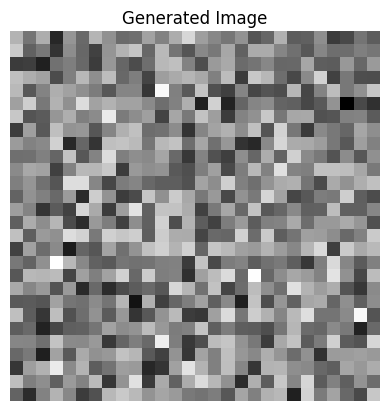

In [ ]:
# Generator
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),

            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Initialize Models
gen = Generator().to(device)
disc = Discriminator().to(device)

# Weight Initialization
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0.0, 0.02)

gen.apply(initialize_weights)
disc.apply(initialize_weights)

# Loss & Optimizers
criterion = nn.BCELoss()

optimizer_g = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_d = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Dummy Training Step
batch_size = 32
noise_dim = 100

real_data = torch.randn(batch_size, 784).to(device)

real_labels = torch.ones(batch_size, 1).to(device)
fake_labels = torch.zeros(batch_size, 1).to(device)

# ---- Train Discriminator ----
gen.train()
disc.train()

noise = torch.randn(batch_size, noise_dim).to(device)
fake_data = gen(noise)

disc_real = disc(real_data)
disc_fake = disc(fake_data.detach())

loss_real = criterion(disc_real, real_labels)
loss_fake = criterion(disc_fake, fake_labels)

loss_d = loss_real + loss_fake

optimizer_d.zero_grad()
loss_d.backward()
optimizer_d.step()

# ---- Train Generator ----
noise = torch.randn(batch_size, noise_dim).to(device)
fake_data = gen(noise)

output = disc(fake_data)
loss_g = criterion(output, real_labels)

optimizer_g.zero_grad()
loss_g.backward()
optimizer_g.step()

# Generate Sample (FIXED)
gen.eval()  # 🔥 IMPORTANT FIX

noise = torch.randn(1, noise_dim).to(device)
fake_image = gen(noise)

gen.train()  # optional

print("Generated image shape:", fake_image.shape)
print("Discriminator loss:", loss_d.item())
print("Generator loss:", loss_g.item())

# Visualize Output
img = fake_image.view(28, 28).detach().cpu().numpy()

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("Generated Image")
plt.show()

# Section 6: Final Mini Project

#### Its inside the folder Final mini project...